In [32]:
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['font.family'] = 'serif'
import numba as nb


In [33]:
@nb.njit()
def quantize(x, nlevels, delta):
    xq = np.round(x/delta)
    maxlevel = (nlevels-1)//2
    xq[xq>maxlevel]=maxlevel
    xq[xq < -maxlevel] = -maxlevel
    return xq

@nb.njit()
def hist(xq, nlevels):
    y = np.zeros(nlevels,dtype="int64")
    nn = len(xq)
    for i in range(nn):
        a = int(xq[i])
        if a >= 0:
            y[a]+=1
        else:
            y[nlevels+a]+=1
    return y
def sinc_hamming(ntap,lblock):
    N=ntap*lblock
    w=np.arange(0,N)-N/2
    win=np.hamming(ntap*lblock)*np.sinc(w/lblock)
    return win

def forward_pfb(timestream, nchan=2048, ntap=4, window=sinc_hamming):
    #old PFB function from CHIME/Steve
    # number of samples in a sub block
    lblock = 2*(nchan)
    # number of blocks
    nblock = timestream.size / lblock - (ntap - 1)
    nblock=int(nblock)

    # initialize array for spectrum 
    spec = np.zeros((nblock,nchan+1), dtype=np.complex128)

    # window function
    w = window(ntap, lblock)

    def s(ts_sec):
        return np.sum(ts_sec.reshape(ntap,lblock),axis=0) # this is equivalent to sampling an ntap*lblock long fft - M


    # iterate over blocks and perform PFB
    for bi in range(nblock):
        # cut out the correct timestream section
        ts_sec = timestream[bi*lblock:(bi+ntap)*lblock].copy()

        spec[bi] = np.fft.rfft(s(ts_sec * w)) 

    return spec

def inverse_pfb(dat,ntap,window=sinc_hamming,thresh=0.0):
    dd=np.fft.irfft(dat,axis=1)
    win=window(ntap,dd.shape[1])
    win=np.reshape(win,[ntap,len(win)//ntap])
    mat=np.zeros(dd.shape,dtype=dd.dtype)
    mat[:ntap,:]=win
    matft=np.fft.rfft(mat,axis=0)
    ddft=np.fft.rfft(dd,axis=0)
    if thresh>0:
        filt=np.abs(matft)**2/(thresh**2+np.abs(matft)**2)*(1+thresh**2)
        ddft=ddft*filt
    return np.fft.irfft(ddft/np.conj(matft),axis=0)

In [34]:
hist([1,2,2,3,3,3,-1,-2,-2,-3,-3,-3], 15)

array([0, 1, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2, 1])

In [35]:
nspec=50003 #generate 50k spectra
lblock=2048
x = np.random.randn(nspec*lblock)

# xq1 = quantize(x,15,0.353)


In [36]:
spec = forward_pfb(x,nchan=1024)

Vraince should be 2048 but it's not because of window normaliztion

In [37]:
np.var(spec) #off by 1.24

np.float64(1649.7533413613594)

In [38]:
win=sinc_hamming(4,lblock)
2048/np.sum(win**2)

np.float64(1.2415035420151284)

In [39]:
sigma_re = np.std(spec.real)
sigma_im = np.std(spec.imag)
print(sigma_re,sigma_im)

28.747558029892133 28.693749296307328


In [40]:
nlevels=15
a = 0.5   # tuning param

print("a is ", a)

delta = a * sigma_re

qspec = quantize(np.ravel(spec.real),nlevels,delta).reshape(-1,lblock//2+1) +\
                                1j * quantize(np.ravel(spec.imag),nlevels,delta).reshape(-1,lblock//2+1)

a is  0.5


In [41]:
delta

np.float64(14.373779014946066)

In [42]:
np.std(np.real(qspec)), 1/a #they line up as one would expect for a well tuned system

(np.float64(2.019934418983832), 2.0)

In [43]:
np.std(np.real(spec/delta)), 1/a #they line up as one would expect for a well tuned system

(np.float64(2.0), 2.0)

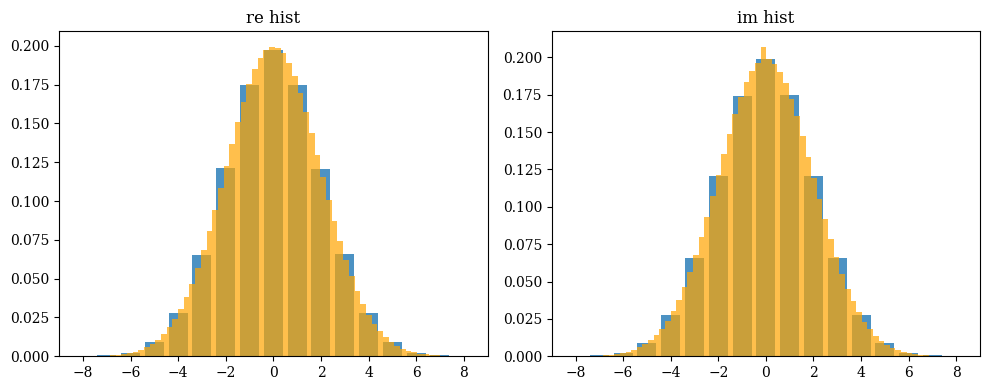

In [44]:
qhistre = hist(np.real(qspec).ravel(),nlevels)
qhistim = hist(np.imag(qspec).ravel(),nlevels)
qbins = np.linspace(-nlevels//2+1, nlevels//2, nlevels)
fig=plt.gcf()
fig.set_size_inches(10,4)

plt.subplot(121)
plt.title("re hist")
plt.bar(qbins,np.fft.fftshift(qhistre)/np.sum(qhistre),alpha=0.8)
out=plt.hist(np.real(spec).ravel()/delta,bins=100,color='orange',alpha=0.7,density=True)
plt.xlim(qbins[0]-2,qbins[-1]+2)
plt.subplot(122)
plt.title("im hist")
plt.bar(qbins,np.fft.fftshift(qhistim)/np.sum(qhistim),alpha=0.8)
out=plt.hist(np.imag(spec).ravel()/delta,bins=100,color='orange',alpha=0.7,density=True)
plt.xlim(qbins[0]-2,qbins[-1]+2)
plt.tight_layout()

In [45]:
qnoise = spec/delta - qspec # Q noise in units of LSB

mean qnoise in units of levels 0.28897918090002844


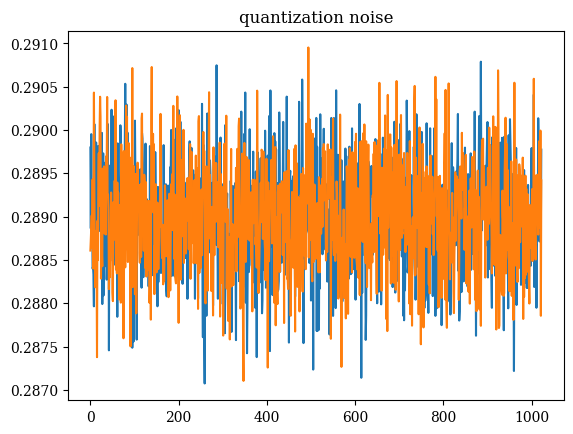

In [46]:
plt.plot(np.std(qnoise.real[:,1:-1],axis=0))
plt.plot(np.std(qnoise.imag[:,1:-1],axis=0))
plt.title("quantization noise")
print("mean qnoise in units of levels", np.mean(np.std(qnoise.real,axis=0)[1:-1]))
#values makes sense. is essentially 1/np.sqrt(12)

### As long as quantizer has enough levels and is well-tuned the noise will be 0.289 LSB

In [47]:
def get_ipfb_ts(qspec, x, lblock, delta, thresh, osamp=32):
    cut = 5
    print("using thresh", thresh)
    qx = inverse_pfb(qspec,ntap=4,thresh=thresh)
    qx_nofilt = inverse_pfb(qspec,ntap=4,thresh=0.)
    qspec_filt = forward_pfb(np.ravel(qx), nchan=lblock//2 * osamp)
    qspec_nofilt = forward_pfb(np.ravel(qx_nofilt), nchan=lblock//2 * osamp)
    st = cut
    en = qspec.shape[0] - cut
    qerror = (np.ravel(qx[st:en,:])- x[st*lblock:en*lblock]/delta)  #/ (x[5*lblock:995*lblock]/delta)
    qerror = qerror.reshape(-1,lblock)
    qerror_rms = np.std(qerror,axis=0)

    qerror_nofilt = (np.ravel(qx_nofilt[cut:en,:])- x[cut*lblock:en*lblock]/delta)#/ (x[5*lblock:995*lblock]/delta)
    qerror_nofilt = qerror_nofilt.reshape(-1,lblock)
    qerror_nofilt_rms = np.std(qerror_nofilt,axis=0)

    return qerror_rms, qerror_nofilt_rms, qerror, qerror_nofilt, qspec_filt, qspec_nofilt

In [48]:
print("SNR in dB", 20*np.log10(np.sqrt(12)/a)) #Everything in units of LSB

SNR in dB 16.812412373755873


ideal value of phi

In [49]:
1/(2*np.sqrt(12)) # in quantized PFB space, ratio is this.

np.float64(0.14433756729740646)

value of phi due to differing window normalization

In [50]:
a/np.sqrt(12)/np.sqrt(1.24) #but in IFFT (PFB) space, the ratio changes a bit due to window normalization

np.float64(0.12961896184130317)

### Calculate ideal non-quantized fine resolution 32x upchan spectra

In [51]:
new_spec = forward_pfb(x, nchan=lblock//2 * 32)
new_spec_mean = np.mean(np.abs(new_spec)**2,axis=0)
sig_x = np.std(x)/delta #everythhing in units of LSB for comparison

In [52]:
thresh=0.129
qerror_rms1, qerror_nofilt_rms1, qerror1, qerror_nofilt1, qspec1, qspec_nofilt1 = get_ipfb_ts(qspec, x, lblock, delta, thresh)
qspec1_mean = np.mean(np.abs(qspec1)**2,axis=0)
qspec_nofilt1_mean = np.mean(np.abs(qspec_nofilt1)**2,axis=0)


using thresh 0.129


In [53]:
#optional to compare effects of badly missing optimal phi

# thresh=0.5
# qerror_rms2, qerror_nofilt_rms2,  qerror2, qerror_nofilt2, qspec2, qspec_nofilt2 = get_ipfb_ts(qspec, x, lblock, delta, thresh)
# qspec2_mean = np.mean(np.abs(qspec2)**2,axis=0)
# qspec_nofilt2_mean = np.mean(np.abs(qspec_nofilt2)**2,axis=0)

New Variance: shouldve been 65536 but it's scaled due to window normalization

In [54]:
np.mean(np.abs(new_spec)**2)

np.float64(52795.10293992769)

In [55]:
np.sum(win**2) *32 #analytical truth

np.float64(52787.606142167104)

In [56]:
colors=plt.get_cmap('Set2').colors # get list of RGB color values

In [57]:

qspec1_meanerr = np.mean(np.abs(qspec1-new_spec/delta)**2,axis=0)/(np.mean(np.abs(new_spec)**2)/delta**2)
qspec2_meanerr = np.mean(np.abs(qspec_nofilt1-new_spec/delta)**2,axis=0)/(np.mean(np.abs(new_spec)**2)/delta**2)


In [58]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
darkcolors = ['#EE5B5B', '#3EBDB4', '#2597B1', '#EF906A']

(4, 2048)
0.000211789594683931
32769


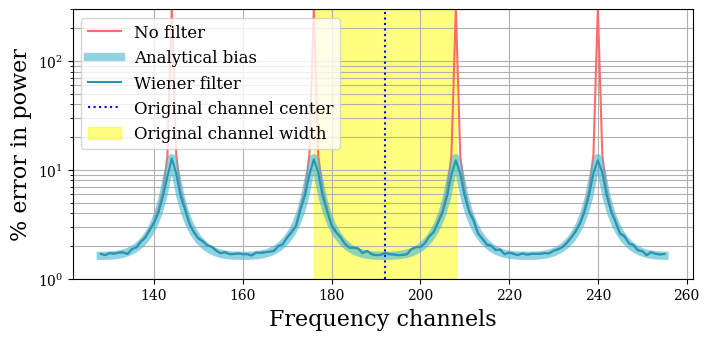

In [71]:
ntap=4
N=2048
win = sinc_hamming(ntap, N)
win=np.reshape(win,[ntap,len(win)//ntap])
print(win.shape)
mat=np.zeros((32, N),dtype='float64') # 1/32 the channel size. that's fine enough for plotting, and makes indexing easy
mat[:ntap,:]=win
matft=np.fft.fft(mat.T,axis=1)
print(np.min(np.abs(matft)))
phi=0.129 #optimal for default window normaliztion convention

yy = 1 - np.mean(np.abs(matft)**2/(np.abs(matft)**2 + phi**2),axis=0) #this is the bias in the PSD of full-rate spectrum

fig=plt.gcf()
fig.set_size_inches(8,3.5)
osamp=32
st=4
en=8
chans = np.arange(len(qspec1_meanerr))
print(len(chans))
sl = slice(st*osamp,en*osamp,None)
plt.semilogy(chans[sl], qspec2_meanerr[sl]*100, label='No filter', color=colors[0])
plt.semilogy(chans[sl],np.tile(yy*100, 4),lw=6, linestyle='-', label='Analytical bias',color=colors[2],alpha=0.6)
plt.semilogy(chans[sl], qspec1_meanerr[sl]*100, label='Wiener filter', color=darkcolors[2])
center=(st+en)//2*osamp
plt.axvline(center, ls='dotted', c='blue', label='Original channel center')
#plt.axvspan(center-16, center+16, color='yellow', alpha=0.5, label='Original channel width')
plt.axvspan(center-16, center+16, color='yellow', alpha=0.5, label='Original channel width')
plt.grid(True,which='both')
plt.legend(loc=2,fontsize=12)
plt.ylim(1,3e2)
plt.ylabel("% error in power", fontsize=16)
plt.xlabel("Frequency channels", fontsize=16)
fig.savefig('img/mohan-spectra-error.png',bbox_inches="tight",dpi=300)

32769


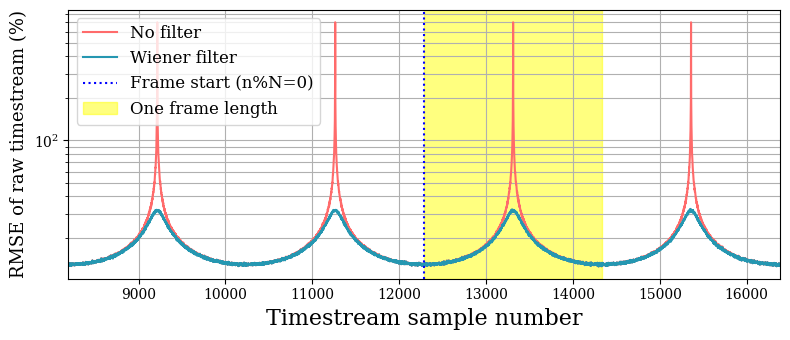

In [74]:
fig=plt.gcf()
fig.set_size_inches(8,3.5)
osamp=32
st=4
en=8
chans = np.arange(len(qspec1_meanerr))
print(len(chans))
sl = slice(st*osamp,en*osamp,None)
plt.semilogy(np.std(qerror_nofilt1.reshape(-1,10,2048),axis=0).ravel()*100/sig_x,color=colors[0], label='No filter')
plt.semilogy(np.std(qerror1.reshape(-1,10,2048),axis=0).ravel()*100/sig_x,color=darkcolors[2], label='Wiener filter')
plt.ylabel("RMSE of raw timestream (%)",fontsize=13)
plt.xlabel("Timestream sample number",fontsize=16)
center=(st+en)//2*2048
plt.axvline(center, ls='dotted', c='blue', label='Frame start (n%N=0)')
plt.axvspan(center, center+2048, color='yellow', alpha=0.5, label='One frame length')
plt.legend(loc=2,fontsize=12)
plt.xlim(st*2048,en*2048)
# plt.ylim(1e1,1e3)
plt.grid(True,which='both')
plt.tight_layout()
fig.savefig('img/mohan-timestream-error.png',bbox_inches="tight",dpi=300)

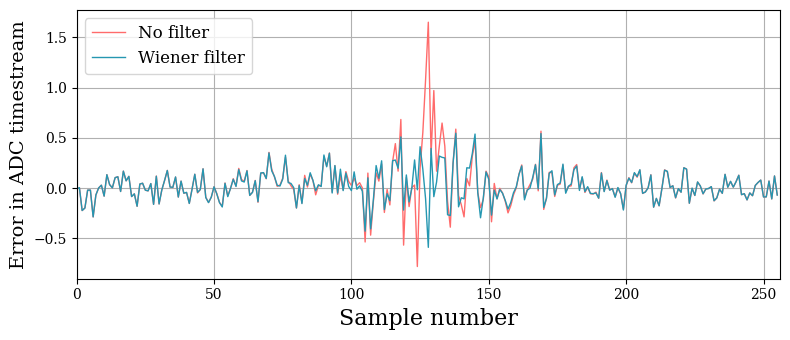

In [84]:
# Single-frame ADC timestream reconstruction: naive iPFB vs Wiener filter.
# Self-contained SHORT-FRAME demo so a single PFB frame is legible: lblock=256
# (128 channels) instead of the 2048 used for the quantitative results, following the
# reviewer's suggestion. Same pipeline and filter params as the RMSE plots
# (a=0.5 quantizer tuning, Wiener thresh=0.129).
ntap = 4
lblock_s = 256                                     # short frame -> one frame is easy to read
nchan_s = lblock_s // 2
nframes_s = 2001                                   # odd -> nblock=1998 is even (needed by inverse_pfb's irfft)
a = 0.5
nlevels = 15
thresh = 0.129

rng = np.random.default_rng(0)                     # seeded for a reproducible figure
x_s = rng.standard_normal(nframes_s * lblock_s)    # true ADC timestream (unit variance)
spec_s = forward_pfb(x_s, nchan=nchan_s, ntap=ntap)
delta_s = a * np.std(spec_s.real)
qspec_s = (quantize(np.ravel(spec_s.real), nlevels, delta_s)
           + 1j*quantize(np.ravel(spec_s.imag), nlevels, delta_s)).reshape(spec_s.shape)
qx_wien  = inverse_pfb(qspec_s, ntap=ntap, thresh=thresh)   # Wiener-filtered reconstruction (LSB)
qx_naive = inverse_pfb(qspec_s, ntap=ntap, thresh=0.)       # naive (unfiltered) reconstruction (LSB)

frame = 1000                                       # an interior frame to display
n = np.arange(lblock_s)
true_f  = x_s[frame*lblock_s:(frame+1)*lblock_s]   # ADC units
naive_f = qx_naive[frame]*delta_s                  # back to ADC units
wien_f  = qx_wien[frame]*delta_s

fig=plt.gcf()
fig.set_size_inches(8,3.5)
std_err = np.std(true_f)
#plt.axvspan(0, lblock_s, color='yellow', alpha=0.25, label='One frame length')
plt.plot(n, (naive_f-true_f)/std_err, color=colors[0], lw=1, label='No filter')
plt.plot(n, (wien_f-true_f)/std_err, color=darkcolors[2], lw=1, label='Wiener filter')
#plt.plot(n, true_f, color='k', ls='dotted', lw=0.8, alpha=0.8, label='True ADC timestream')
plt.xlim(0, lblock_s)
# plt.ylim(-5, 5)                                    # naive diverges at the frame edges; clip so the signal stays readable
plt.xlabel("Sample number", fontsize=16)
plt.ylabel("Error in ADC timestream", fontsize=14)
plt.legend(loc=2, fontsize=12)
plt.grid(True, which='both')
plt.tight_layout()
fig.savefig('img/mohan-timestream-recon.png', bbox_inches="tight", dpi=300)

In [76]:
# fig=plt.gcf()
# fig.set_size_inches(10,6)
# plt.semilogy(qerror_rms1*100/sig_x, label='Wiener filter', color=colors[0])
# plt.semilogy(qerror_nofilt_rms1*100/sig_x, label='No filter', color=colors[1])
# chanstart = 10
# chanend = 14
# center =  (chanstart + chanend)*32//2
# thresh=0.129
# plt.axhline(100*thresh,c='black',ls='--', label='Theoretical % err')
# plt.ylabel("RMSE of raw timestream (%)",fontsize=16)
# plt.xlabel("PFB frame sample number",fontsize=16)
# plt.title(f"Timestream error across one frame",fontsize=20)
# plt.legend(loc=2,fontsize=12)
# plt.grid(which='both')
# plt.ylim(1e1,1e3)
# plt.tight_layout()
# fig.savefig('timestream_error_frame.png',bbox_inches="tight",dpi=300)
# # plt.xlim(32*10-16,32*14+16)


In [77]:

# qspec1_meanerr = np.mean(np.abs(qspec1-new_spec/delta)**2,axis=0)/(np.mean(np.abs(new_spec)**2)/delta**2)
# qspec2_meanerr = np.mean(np.abs(qspec2-new_spec/delta)**2,axis=0)/(np.mean(np.abs(new_spec)**2)/delta**2)


# fig=plt.gcf()
# fig.set_size_inches(10,6)
# plt.semilogy(qspec1_meanerr*100, label='$\phi=0.129$', color=colors[0])
# plt.semilogy(qspec2_meanerr*100, label='$\phi=0.5$', color=colors[1])
# chanstart = 10
# chanend = 14
# center =  (chanstart + chanend)*32//2
# thresh=0.129
# plt.axhline(100*thresh**2/(thresh**2 + 1),c='black',ls='--', label='Theoretical % err')
# plt.ylabel("Error in power (%)",fontsize=16)
# plt.xlabel("Frequency channels",fontsize=16)
# plt.title(f"32x up-channelized spectrum",fontsize=20)
# plt.axvline((chanend+chanstart)*32//2, ls='dotted', c='blue', label='Original channel center')
# plt.axvspan(center-16, center+16, color='yellow', alpha=0.7, label='Original channel width')
# plt.legend(loc=2,fontsize=12)
# plt.xlim(32*10-16,32*14+16)
# # plt.grid(True,which='both')
# plt.tight_layout()
# fig.savefig('spectra_error_two_phi.png',bbox_inches="tight",dpi=300)